<a href="https://colab.research.google.com/github/YingxueZhang01/2026Winter/blob/main/deliverable_01_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deliverable 1: Radiation Physics and Image Quality**

---

## Overview

This deliverable covers foundational and advanced concepts from **Weeks 2-5** (Lectures 1-12) of the course. You will explore:
1. Radiation physics and ionizing radiation
2. X-ray production and energy scales
3. Photon-matter interactions (photoelectric, Compton, attenuation)
4. Spatial resolution and system blurring
5. Linear systems, MTF, and image sharpness
6. Noise sources, SNR, and image quality
7. Quantum noise, dose optimization, and trade-offs
8. Comprehensive design challenge for imaging protocols

You will engage with the material through a combination of conceptual questions and guided coding exercises designed to strengthen physical intuition and practical problem-solving skills. By the end of this deliverable, you will be able to interpret imaging trade-offs, analyze image quality metrics, and make informed decisions when optimizing imaging protocols for clinical applications.

---
## **<u>Part 1: Radiation Physics</u>**

### 1.1 Ionizing Radiation Classification and Energy Scales

**Key Concept:**
Radiation is classified by whether it has enough energy to knock electrons out of atoms (ionization). This happens when the photon energy exceeds the **ionization potential** of an atom (~13.6 eV for hydrogen).

**Energy Classification:**
- **Non-ionizing:** Visible light (1.6-3.1 eV), radio waves (<0.00001 eV)
  - Energy too low to ionize atoms
  - Cannot damage DNA directly
  
- **Ionizing:** X-rays (keV range), gamma rays (keV-MeV range)
  - High enough energy to remove electrons from atoms
  - Can damage living tissue and DNA
  - Used in medical imaging (controlled exposure)

**Key Equation:**
$$E = h\nu = \frac{hc}{\lambda}$$

- Where:
    - h = 6.626×10⁻³⁴ J·s (Planck's constant)
    - c = 3×10⁸ m/s (speed of light)

### **Question 1**

**Scenario:** A patient asks why a chest X-ray is "safe" but they worry about radiation exposure.

Using the concepts above, answer:
- (a) Why is a chest X-ray classified as ionizing radiation? What does "ionizing" mean?

- (b) A chest X-ray delivers ~0.1 mSv. A CT scan delivers ~7 mSv (70× higher). What does this mean for radiation dose to the patient?

**My answers:**

(a) A chest X-ray involves ionizing radiation because its photon energy falls in the KeV range, which is higher than the ionization potential of atoms. Ionizing means the radiation carries enough energy to knock electrons out of their atomic orbits. This process can alter the chemical properties of molecules and may even damage DNA.

(b) Radiation dose reflects the biological risk. The 0.1 mSv dose from a chest X-ray is very low, roughly equivalent to the amount of natual background radiation a person receives over about 10 - 15 days on earth, from sources like soil, air, and food. It's generally considered safe. In contrast, a CT scan exposes people to about 70 times more radiation, which greatly increases the potential for tissue damage and means it should only be done when there's a strong medical reason.

### 1.2 X-ray Production

**X-ray Generation:**
X-rays are produced when high-energy electrons strike a metal target (usually tungsten).

**Two Production Mechanisms:**

1. **Bremsstrahlung (Braking Radiation):**
   - Electron decelerates near nucleus
   - Loses kinetic energy → emitted as X-ray photon
   - Produces **continuous spectrum** of energies
   - Maximum energy = tube voltage (kVp)
   - Accounts for ~80% of X-ray output

2. **Characteristic X-rays:**
   - Electron knocks out inner shell electron
   - Outer electron fills vacancy
   - Energy difference emitted as X-ray
   - Produces **discrete spectral lines** (specific energies)
   - Depends on target material (e.g., K-alpha, K-beta lines for tungsten)

**X-ray Spectrum:**
- Shape determined by tube voltage (kVp) and filtration
- Higher kVp → higher maximum energy and intensity
- Filtration removes low-energy photons (patient protection)

**Key Equation:**
$$E_{max} = eV_{peak}$$
- Where:
   - $V_{peak}$ is the peak tube voltage in kV

### **Question 2**

An X-ray tube operates at 100 kVp with a tungsten target.

- a) What is the maximum energy (in keV) of X-ray photons that can be produced?

- b) Explain the difference between bremsstrahlung and characteristic X-rays. Which one produces the continuous spectrum and which produces discrete peaks?

- c) Why do we use filtration (typically aluminum) at the X-ray tube output? What effect does this have on the X-ray spectrum and patient dose?

**My Answers:**

(a) The maximum energy is directly set by the tube's peak voltage. Since the X-ray tube runs at 100 kVp, the highest photon energy is 100 keV. This happens when an electron gives up all its kinetic energy in one go through the Bremsstrahlung.

(b) Bremsstrahlung happens when electrons slow down as they pass near a nucleus, releasing X-rays with a continuous range of energies. Characteristic X-rays, on the other hand, are produced when inner-shell electrons are ejected and outer electrons fall into their place, giving off photons with specific energy differences that form distinct spectral peaks unique to the target material.

(c) Filtration is used to absorb low energy photons that don't contribute to image formation because they can't penetrate the patient's body and would just be absorbed instead. By removing them, filration shifts the spectrum toward higher average energy and greatly reduces the radiation dose to the patient.

---

## **<u>Part 2: Photon Interactions</u>**

### 2.1 Interaction Types

**Key Concept:**
When X-rays pass through tissue, they interact through different mechanisms depending on photon energy and material properties.

**Main Interaction Types:**

1. **Photoelectric Effect** (low energy, high-Z materials)
   - X-ray photon absorbed completely
   - Electron kicked out of atom
   - Useful for imaging (produces signal)
   - Why: Bone (high Z) appears bright

2. **Compton Scattering** (medium-high energy)
   - Photon deflected and loses energy
   - Electron recoils
   - Scattered photons reduce image contrast (noise)
   - Why: Anti-scatter grids are used

Refer to the schematic below:

<p align="center">
  <img src="figures/scatter_effect_example.jpg" width="600">
</p>

This illustrates how Compton-scattered photons reach the detector and reduce image contrast, and how anti-scatter grids selectively absorb these scattered photons while allowing primary radiation to pass.

3. **Pair Production** (very high energy, >1.02 MeV)
   - Rare in medical imaging
   - Not important for X-rays (typically 20-150 keV)

**Attenuation:**
X-rays passing through material follow the **Beer-Lambert Law**:
$$I = I_0 e^{-\mu x}$$

- where:
    - $I$ = transmitted intensity
    - $I_0$ = incident intensity
    - $\mu$ = linear attenuation coefficient (material dependent)
    - $x$ = material thickness

### **Question 3**

Consider an X-ray imaging system operating at 80 keV.

- a) At this energy, both photoelectric absorption and Compton scattering occur. Which interaction mechanism is more likely to dominate in bone tissue versus soft tissue, and why? (Hint: Consider the atomic number dependence)

- b)Explain why Compton scattered photons are problematic for image quality. What specific image quality metric do they degrade?

- c) X-ray imaging systems use anti-scatter grids to reduce the detection of scattered photons. If a grid removes 80% of scattered photons but also blocks 20% of primary (unscattered) photons, when would you choose to use the grid versus imaging without it? Consider both image quality and patient dose.

- d) In CT imaging, we use higher energies (120-140 keV) compared to conventional radiography (60-80 keV). Based on the energy dependence of photoelectric and Compton interactions, how does this affect the contrast between bone and soft tissue in CT images?

**My Answers:**

(a) In bone, the photoelectric effect is the dominant interaction because calcium has a high atomic number. In soft tissues, which have much lower atomic numbers, Compton scattering becomes more significant, since the photoelectric effect quickly decreases when there aren't high Z materials to absorb the photons.

(b) Compton scattered photons change direction and strike the detector at random positions, adding a layer of fog or noise instead of true anatomical information. This reduces image contrast, and makes the image appear washed out or gray.

(c) A grid is used for thick or dense body parts such as the abdomen where scatter is high. The grid blocks scattered radiation and greatly improves image contrast. Since it also blocks some of the primary beam, the exposure and radiation dose need to be increased. For thinner parts such as the hand, the grid can be left out to reduce the patient’s dose.

(d) At higher energies, the likelihood of the photoelectric effect decreases sharply. As a result, the contrast between bone and soft tissue is lower in CT than in low-energy X-rays.

### 2.2 Beer-Lambert Law & Attenuation

**Attenuation** describes how X-ray intensity decreases as it passes through material.

**Beer-Lambert Law:**
$$I = I_0 e^{-\mu x}$$

- Where:
    - $I$ = transmitted intensity
    - $I_0$ = incident intensity  
    - $\mu$ = linear attenuation coefficient (cm⁻¹) - material dependent
    - $x$ = material thickness (cm)

**Half-Value Layer (HVL):**
- Thickness of material that reduces intensity to 50%
- Related to attenuation coefficient: $HVL = \frac{\ln(2)}{\mu} = \frac{0.693}{\mu}$
- Lower HVL = more attenuation (denser material or lower energy)

**Key Insight:**
- Bone has higher μ than soft tissue → more attenuation → appears bright
- Different energies attenuate differently (energy dependence)
- HVL is a practical measure used in X-ray quality control

### **Question 4**

A 60 keV X-ray beam passes through soft tissue with linear attenuation coefficient μ = 0.2 cm⁻¹.

- a) If the incident intensity is $I_0 = 10,000$ photons, what is the transmitted intensity after passing through 5 cm of tissue? Use the Beer-Lambert law.

- b) Calculate the Half-Value Layer (HVL) for this tissue at 60 keV.

- c) If you increase the X-ray energy from 60 keV to 120 keV, the attenuation coefficient decreases to μ = 0.15 cm⁻¹. What happens to the transmitted intensity through the same 5 cm of tissue? Calculate the new transmitted intensity and explain why higher energy X-rays penetrate better.

**My Answers:**

(a) I = 10000 * e^((-0.2)*5) = 10000 * e^(-1) ≈ 3679

(b) HVL = 0.693 / μ = 0.693 / 0.2 cm^(-1) = 3.465 cm

(c) I(new) = 10000 * e^((-0.15)*5) = 10000 * e^(-0.75) ≈ 4724

Higher energy X-rays have a lower attenuation coefficient (μ) because they are less likely to interact with atoms (less photoelectric effect). Therefore, they penetrate material more easily, resulting in higher transmission intensity compared to lower energy beams.

---

## **<u>Part 3: Spatial Resolution</u>**

### 3.1 Point Spread Function (PSF) and System Blurring

**Key Concept:**

Real imaging systems are **imperfect**. A point source (infinitely small object) doesn't appear as a point in the image—it appears as a **blurred blob**. This blurring limits how small an object you can see.

**Point Spread Function (PSF):**
- **PSF** = How much a point source gets blurred by the imaging system
- **Shape:** Usually Gaussian-like (bell curve)
- **Width:** Characterized by **FWHM** (Full Width at Half Maximum)
  - Smaller FWHM = sharper system (better resolution)
  - Larger FWHM = blurrier system (worse resolution)


**Resolution Rule of Thumb:** You can distinguish two objects only if they're separated by at least the **FWHM of the PSF**. Anything closer just blurs together.

**Image Formation:**

$$\text{Blurred Image} = \text{Sharp Object} \otimes \text{PSF}$$

  - The $\otimes$ symbol means "convolved with"—every sharp point gets replaced by a blurred copy (PSF shape).

**Real Example - Chest X-ray:**
- System resolution: ~0.2 mm FWHM
- Lung nodule: 3-4 mm → **Visible** (15-20× larger than PSF)
- Micro-calcification: 1-3 mm → **Borderline** (5-15× larger)
- Small vessel: 0.5 mm → **Invisible** (blurs away)

### **Question 5**

You're designing an X-ray detector system for mammography, where high resolution is critical to detect small microcalcifications (~100 μm).

- a) If your current detector has a PSF with FWHM = 200 μm, can you reliably detect 100 μm objects? Explain your reasoning using the relationship between FWHM and object size.

- b) You have two detector options:
   - **Detector A**: 50 μm pixels, FWHM = 100 μm, readout time = 5 seconds
   - **Detector B**: 100 μm pixels, FWHM = 200 μm, readout time = 1 second
   
   Which detector would you choose for mammography and why? Consider resolution requirements, patient motion, and clinical workflow.

- c) In PET imaging, using smaller detector crystals improves spatial resolution but also increases system cost and complexity. If you could reduce FWHM from 5 mm to 2.5 mm (2× improvement) at a 3× increase in cost, what clinical applications would justify this investment? Name at least two specific imaging tasks where the improved resolution would significantly impact diagnosis.

**My Answers:**

(a) No, it cannot be reliably detected. The object which is 100 micrometers wide, is smaller than the system's blur size, with a full width at half maximum of 200 micrometers. As the text explains, objects need to be much larger than the point spread function to appear clearly. When an object is only half the blur size, its signal spreads out, lowering the contrast until it blends in and disappears.

(b) I would choose Detector A. Mammography focuses on detecting microcalcifications around 100 micrometers, so high resolution with a 100 micrometer full width at half maximum is essential. Detector B, with 200 micrometers of blur, would make these details too hard to see. Although the 5s readout time increases the risk of patient motion, breast Immobilization helps keep movement to a minimum, making this trade-off worthwhile for the image sharpness needed.

(c) First, justifiable applications include neurology, such as detecting small epileptic foci or early Alzheimer's plaques.
Second, early oncology also benefits, for example in identifying tiny metastatic lymph nodes or lung nodules smaller than five millimeters.
improving the resolution to 2.5 mm enables doctors to diagnose diseases at a much earlier stage, which can greatly influence treatment decisions and makes the higher cost worthwhile.

### 3.2 Linear Systems Theory & MTF

**Linear Systems Theory:**
Medical imaging systems can be modeled as linear, shift-invariant systems.

**Key Properties:**
1. **Linearity:** If input doubles, output doubles
2. **Shift Invariance:** System response doesn't depend on position
3. **Convolution:** Image formation is described by convolution with PSF
   $$\text{Image} = \text{Object} \otimes \text{PSF}$$

**Modulation Transfer Function (MTF):**
- MTF is the **Fourier transform of the PSF**
- Measures how well the system reproduces different spatial frequencies
- MTF ranges from 0 (no reproduction) to 1 (perfect reproduction)
- **Spatial frequency** measured in cycles/mm or line pairs/mm

**Interpreting MTF:**
- MTF = 1.0 at low frequencies → large objects reproduced perfectly
- MTF decreases at high frequencies → fine details are blurred
- **MTF at 50%** (where MTF = 0.5) is often used as resolution metric
- Related to FWHM: Better resolution → higher MTF at high frequencies

**Example:**
- System A: MTF = 0.5 at 5 cycles/mm → can resolve 0.1 mm details
- System B: MTF = 0.5 at 10 cycles/mm → better, can resolve 0.05 mm details

### **Question 6**

You are comparing two X-ray detector systems:

| System | MTF at 2 cycles/mm | MTF at 5 cycles/mm | MTF at 10 cycles/mm |
|--------|-------------------|-------------------|---------------------|
| System A | 0.95 | 0.70 | 0.30 |
| System B | 0.90 | 0.50 | 0.10 |

- a) Which system has better spatial resolution? Explain your reasoning using the MTF values.

- b) For detecting a 1 mm lesion (which contains frequencies around 1-2 cycles/mm), which system would be more suitable?

- c) Explain the relationship between MTF and PSF. How are they related mathematically, and what does each tell us about the imaging system?


**My Answers**

(a) System A has better spatial resolution. Resolution depends on how the system performs at high spatial frequencies, which represent fine iamge details. At 10 cycles/mm, system A maintains an MTF of 0.30, which system B falls to 0.10. This shows that the system A preserves about three times more contrast for fine details than system B.

(b) Although both systems are capable, system A is more suitable. At low spatial frequencies of 2 cycles/mm, system A achieves an MTF of 0.95, slightly higher than system B's 0.90 .

(c) Mathmatically, the MTF is the magnitude of the Fourier Transform of the PSF. Both describe the same system blurring but in different domains. The PSF in the spatial domain, shows how a single point spreads into a blur. The MTF in the frequency domain, shows how much contrast is retained for details of different sizes of frequencies.

---

## **<u>Part 4: Noise & Image Quality</u>**

### 4.1 Understanding Image Noise

**Quantum (Poisson) Noise** is the primary noise source in X-ray and nuclear imaging:

- Arises from the random nature of photon emission and detection
- Follows **Poisson statistics**: if we detect N photons on average, the noise (standard deviation) is $\sigma = \sqrt{N}$
- **Signal-to-Noise Ratio (SNR)**: $SNR = \frac{N}{\sigma} = \frac{N}{\sqrt{N}} = \sqrt{N}$

**Key insights:**
- SNR increases with the square root of photon count
- To double SNR, you need 4× more photons (4× more dose)
- **Rose Criterion**: Objects are detectable when SNR ≥ 5

**Noise reduction strategies:**
1. Increase photon count (higher dose)
2. Spatial averaging (smoothing filters)
3. Temporal averaging (multiple acquisitions)

Below is an example of a noisy MRI image:

<p align="center">
  <img src="figures/MRI_Highnoise.jpg" width="400">
</p>

### **Coding Exercise 1**

In this exercise, you will implement and compare two different denoising filters:
1. **Gaussian filter** - Simple smoothing
2. **Median filter** - Edge-preserving, good for impulse noise

Your task is to:
- Implement both filters with appropriate parameters
- Calculate the Peak Signal-to-Noise Ratio (PSNR) for each filtered image
- **Choose the best filter** for this medical image and justify your choice

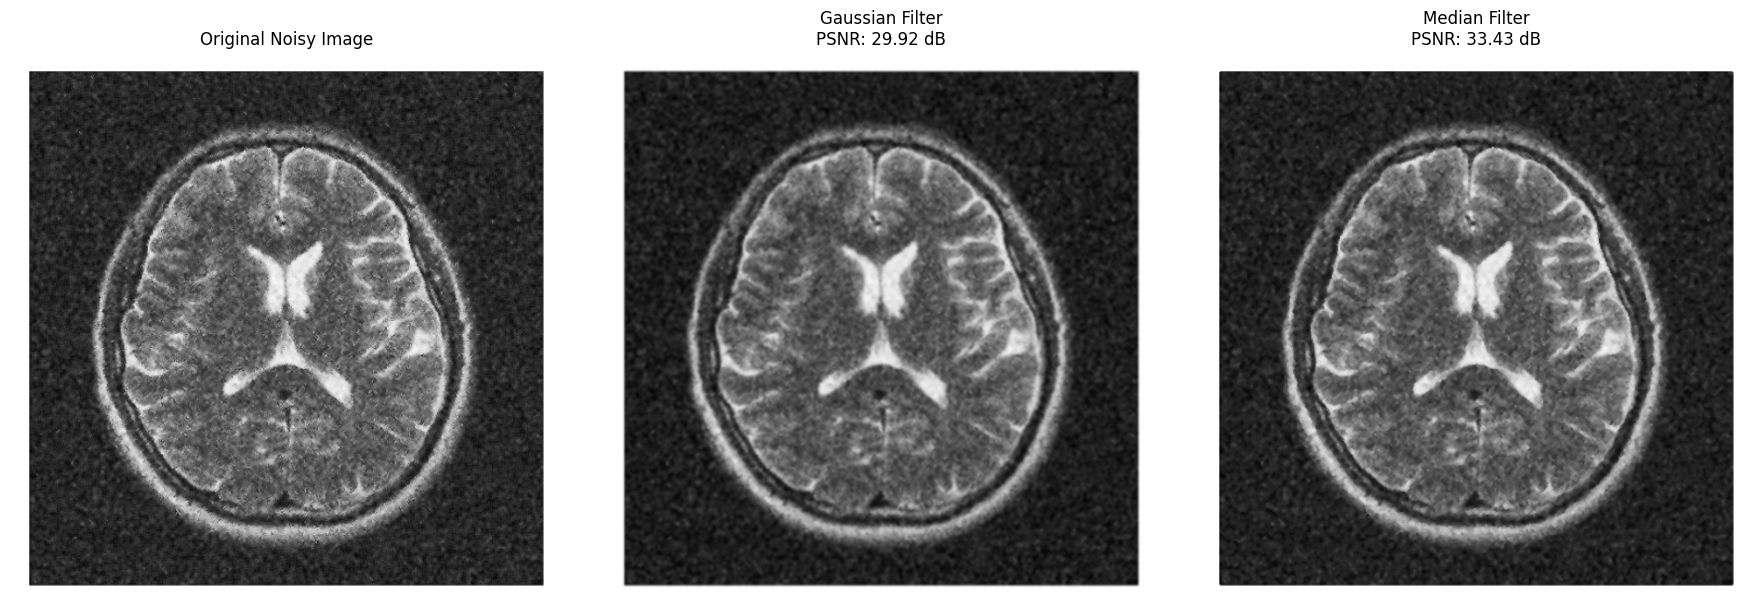

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, median_filter

# Load the noisy MRI image
img = Image.open('figures/MRI_Highnoise.jpg').convert('L')  # Convert to grayscale
img_array = np.array(img, dtype=float)

# Implement both different filters
    # Hint: Try different parameter values to optimize each filter

sigma = 1.0                  # TODO: choose sigma
kernel_size = 3            # TODO: choose median size (odd integer)

# 1. Gaussian filter (adjust sigma)
img_gaussian = gaussian_filter(img_array, sigma=sigma)  # TODO: Optimize sigma

# 2. Median filter (adjust size)
img_median = median_filter(img_array, size=kernel_size)  # TODO: Optimize size

# Calculate PSNR for each filtered image
def calculate_psnr(original, filtered):
    """
    Calculate Peak Signal-to-Noise Ratio
    PSNR = 10 * log10(MAX^2 / MSE)
    where MSE is the mean squared error
    """
    # Implement PSNR calculation
        # Hint: For images, MAX is typically 255 for 8-bit images
    mse = np.mean((original - filtered) ** 2)        # TODO
    max_pixel = 255.0  # TODO
    psnr = 10 * np.log10(max_pixel**2 / mse)       # TODO
    return psnr

# Calculate PSNR for a reference (you'll need to think about what reference to use)
# For demonstration, we'll calculate PSNR relative to the original noisy image
# In practice, you'd want a ground truth clean image

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

axes[1].imshow(img_gaussian, cmap='gray')
axes[1].set_title(f'Gaussian Filter\nPSNR: {calculate_psnr(img_array, img_gaussian):.2f} dB')
axes[1].axis('off')

axes[2].imshow(img_median, cmap='gray')
axes[2].set_title(f'Median Filter\nPSNR: {calculate_psnr(img_array, img_median):.2f} dB')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Your Analysis:

- a) Which filter did you choose and why?

**My Answers:**

I would choose the median filter. Visually, it keeps the sharp edges of brain structures such as the white ventricles clearer than the Gaussian filter, which tends to make the image look blurred. Mathematically, the higher PSNR of 33.43 decibels compared to 29.92 shows that it preserves image quality more effectively.

### 4.2 Detective Quantum Efficiency (DQE)

**DQE** measures how efficiently an imaging system uses the incoming radiation to produce image information.

**Definition:**
$$DQE = \frac{SNR_{out}^2}{SNR_{in}^2}$$

Where:
- $SNR_{out}$ = signal-to-noise ratio in the output image
- $SNR_{in}$ = signal-to-noise ratio in the input radiation

**Key Concepts:**
- DQE ranges from 0 to 1 (or 0% to 100%)
- **Perfect detector:** DQE = 1 (no noise added by detector)
- **Real detectors:** DQE < 1 (detector adds noise)
- Higher DQE = better detector (more efficient use of radiation)

**Practical Implications:**
- High DQE detector → need less radiation dose for same image quality
- DQE depends on spatial frequency (usually decreases at high frequencies)
- DQE depends on exposure level (often highest at moderate exposures)

**Example:**
- Film/screen: DQE ≈ 0.3-0.4 (30-40%)
- Digital radiography (DR): DQE ≈ 0.6-0.7 (60-70%)
- DR systems allow lower dose for same image quality

### **Question 7**

Two X-ray detector systems are being compared:

- **System A (Film/Screen):** DQE = 0.35, cost = $10,000
- **System B (Digital DR):** DQE = 0.70, cost = $50,000

Both systems receive the same input radiation with $SNR_{in} = 100$.

- a) Calculate the output SNR for each system.

- b) If you want to achieve the same output SNR with System A as System B naturally produces, by what factor would you need to increase the radiation dose to System A?

- c) In a high-volume clinical setting performing 100 chest X-rays per day, discuss whether the higher cost of System B is justified. Consider patient dose, image quality, and long-term patient safety.

**My Answers:**

(a)
    SNR of System A: 100 * (0.35)^(1/2) ≈ 59.2

    SNR of System B: 100 * (0.70)^(1/2) ≈ 83.7

    System B produces a significantly clearer image (higher SNR) using the exact same amount of input radiation.

(b) You need to double the dose. System A with a DQE of 0.35, is exactly half as efficient as System B which has a DQE of 0.70. Because System A loses more signal, it requires twice as many input photons to produce the same image quality.

(c) Yes, it is well justified. In a high-volume environment with around 100 patients per day, System B makes it possible to cut radiation dose by 50% for each patient while keeping the same image quality. This major reduction in total population exposure supports the safety principle and easily outweighs the one-time cost difference of $40,000.

---

## **<u>Part 5: Quantum Noise & Dose Analysis</u>**

### **Coding Exercise 2**

In this exercise, simulate the effect of photon counting statistics on image quality. You will:
- Generate a simple "phantom" image
- Add Poisson noise at different dose levels
- Calculate SNR as a function of photon count
- Verify the theoretical relationship: $SNR = \sqrt{N}$

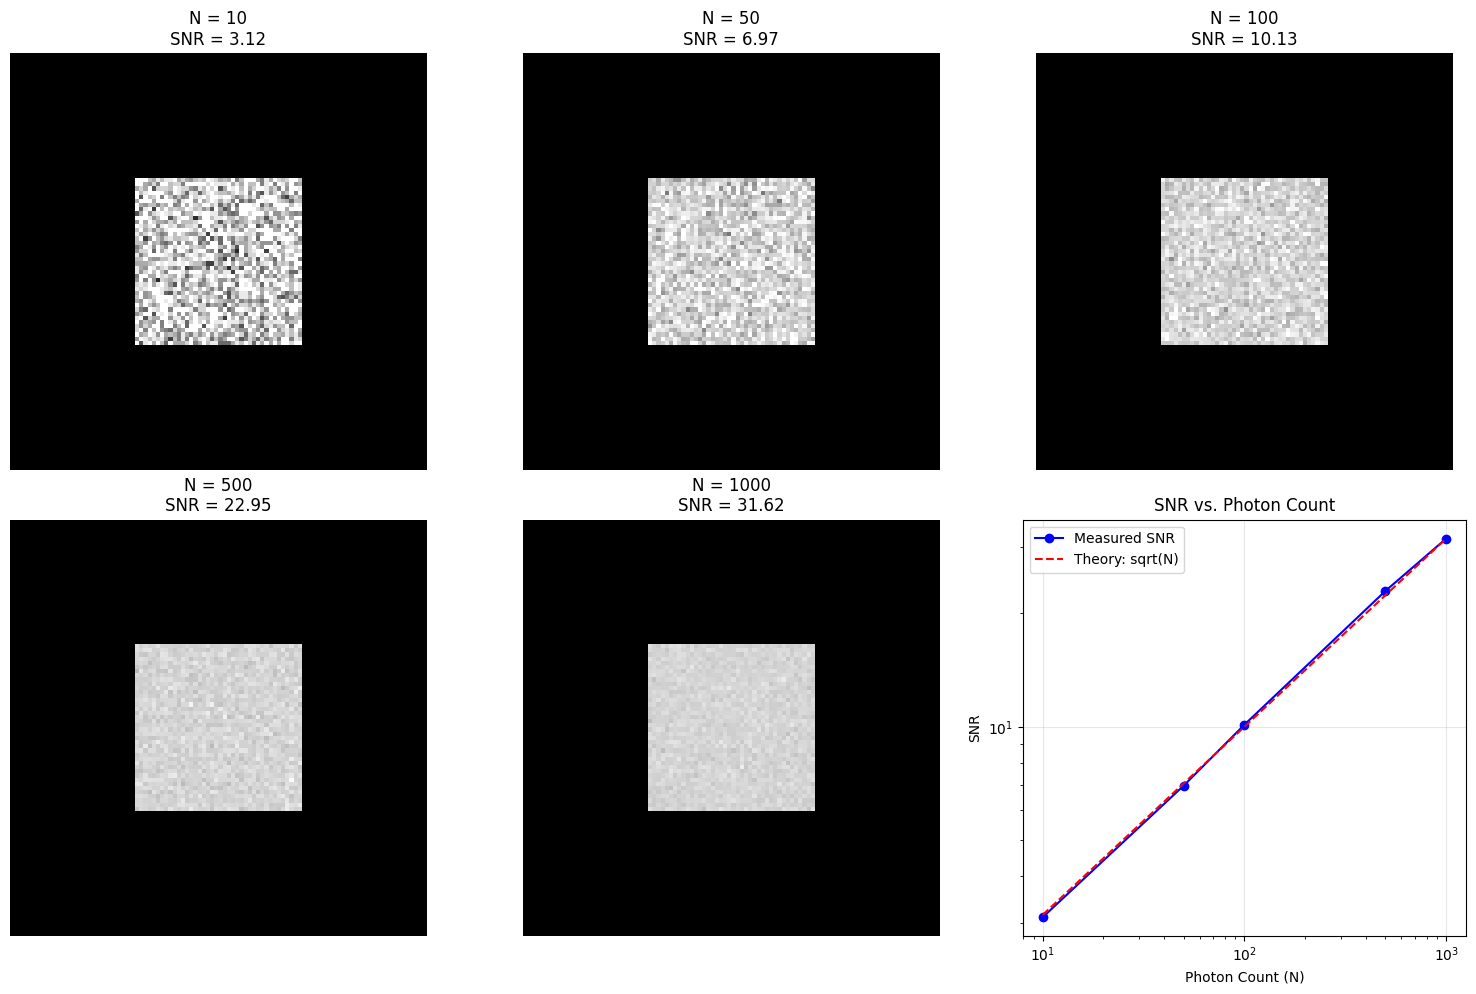


Dose levels and corresponding SNR:
N =   10 photons: SNR = 3.12 (Theory: 3.16)
N =   50 photons: SNR = 6.97 (Theory: 7.07)
N =  100 photons: SNR = 10.13 (Theory: 10.00)
N =  500 photons: SNR = 22.95 (Theory: 22.36)
N = 1000 photons: SNR = 31.62 (Theory: 31.62)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple phantom (uniform square in background)
phantom = np.zeros((100, 100))
phantom[30:70, 30:70] = 1.0  # Square with intensity 1.0

# Define different photon dose levels (mean photons per pixel)
dose_levels = [10, 50, 100, 500, 1000]
snr_measured = []

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, N_photons in enumerate(dose_levels):
    # Generate Poisson noise
        # Hint: Scale phantom by N_photons, apply Poisson noise, then normalize back
    noisy_phantom = np.random.poisson(phantom * N_photons) / N_photons        # TODO

    # Calculate SNR in the central square region
    signal_region = noisy_phantom[30:70, 30:70]
    background_region = noisy_phantom[0:20, 0:20]

    signal_mean = np.mean(signal_region)        # TODO
    background_mean =  np.mean(background_region)        # TODO
    noise_std = np.std(signal_region)        # TODO

    snr = signal_mean / noise_std        # TODO
    snr_measured.append(snr)

    # Display noisy phantom
    axes[idx].imshow(noisy_phantom, cmap='gray', vmin=0, vmax=1.2)
    axes[idx].set_title(f'N = {N_photons}\nSNR = {snr:.2f}')
    axes[idx].axis('off')

# Plot SNR vs. N (log-log scale)
axes[5].loglog(dose_levels, snr_measured, 'bo-', label='Measured SNR')

# Plot theoretical SNR = sqrt(N) for comparison
theoretical_snr = np.sqrt(dose_levels)        # TODO
axes[5].loglog(dose_levels, theoretical_snr, 'r--', label='Theory: sqrt(N)')
axes[5].set_xlabel('Photon Count (N)')
axes[5].set_ylabel('SNR')
axes[5].set_title('SNR vs. Photon Count')
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDose levels and corresponding SNR:")
for N, snr in zip(dose_levels, snr_measured):
    print(f"N = {N:4d} photons: SNR = {snr:.2f} (Theory: {np.sqrt(N):.2f})")

Your Analysis:

- a) Do your measurements agree with the theoretical prediction? If there are differences, what might explain them?

**My Answers:**

Yes, the measurements are in good agreement with the theory. The graph shows the measured SNR curve in blue almost perfectly overlapping the theoretical N^(1/2) line in red. Minor differences, such as 30.73 versus 31.62, are normal and result from statistical variation.

### **Coding Exercise 3**

You're tasked with determining the minimum radiation dose needed for three different clinical scenarios:

1. **Routine chest X-ray** - Need to detect 5 mm nodules (require SNR ≥ 5)
2. **Diagnostic CT** - Need to detect 2 mm lesions (require SNR ≥ 8)
3. **High-risk screening** - Need to detect 1 mm microcalcifications (require SNR ≥ 10)

Given that your baseline protocol delivers N₀ = 1000 photons and achieves SNR₀ = 10 for a 5 mm object:

**Calculate:**
- a) Required photon count for each scenario

- b) Relative dose compared to baseline

In [ ]:
# Baseline values
N0 = 1000  # photons
SNR0 = 10  # for 5 mm object

# Calculate required photon counts for each scenario
    # Hint: Use SNR = sqrt(N) and scale appropriately

scenarios = [
    {'name': 'Routine Chest X-ray', 'size_mm': 5, 'required_snr': 5},
    {'name': 'Diagnostic CT', 'size_mm': 2, 'required_snr': 8},
    {'name': 'High-risk Screening', 'size_mm': 1, 'required_snr': 10}
]

print("Dose Optimization Results:")
print("=" * 70)

for scenario in scenarios:
    # Calculate required N and relative dose
    # Consider both SNR requirements and object size

    required_N = N0 * (scenario['required_snr'] / SNR0)**2 * (5 / scenario['size_mm'])**2        # TODO
    relative_dose =  required_N / N0        # TODO

    print(f"\n{scenario['name']}:")
    print(f"  Object size: {scenario['size_mm']} mm")
    print(f"  Required SNR: {scenario['required_snr']}")
    print(f"  Required photons: {required_N:.0f}")
    print(f"  Relative dose: {relative_dose:.2f}x baseline")

Dose Optimization Results:

Routine Chest X-ray:
  Object size: 5 mm
  Required SNR: 5
  Required photons: 250
  Relative dose: 0.25x baseline

Diagnostic CT:
  Object size: 2 mm
  Required SNR: 8
  Required photons: 4000
  Relative dose: 4.00x baseline

High-risk Screening:
  Object size: 1 mm
  Required SNR: 10
  Required photons: 25000
  Relative dose: 25.00x baseline


### **Coding Exercise 4**

Create a 2D analysis showing how image quality metrics vary with both radiation dose and detector pixel size.

You will create a heatmap showing the "detectability index" (combining SNR and resolution) as a function of:
- X-axis: Radiation dose (relative to baseline)
- Y-axis: Detector pixel size

This helps visualize the complex trade-offs in imaging system design.

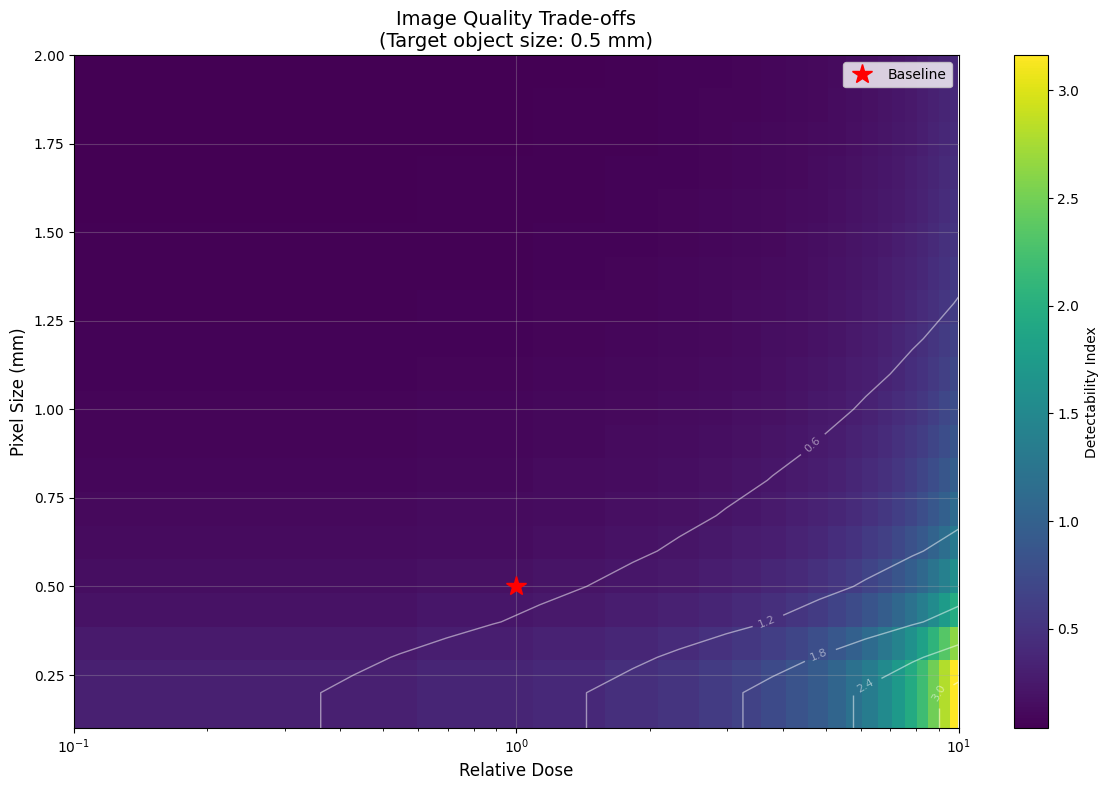

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameter ranges
dose_range = np.logspace(-1, 1, 20)  # 0.1x to 10x baseline dose
pixel_size_range = np.linspace(0.1, 2.0, 20)  # 0.1 to 2.0 mm pixels

# Target object size (mm)
target_size = 0.5  # mm

# Calculate detectability index for each combination
# Detectability ∝ SNR × (resolution_factor)
# where resolution_factor decreases as pixel_size approaches target_size

detectability = np.zeros((len(pixel_size_range), len(dose_range)))        # TODO

for i, pixel_size in enumerate(pixel_size_range):
    for j, dose in enumerate(dose_range):
        # Calculate detectability
        # SNR component from dose
        snr_component = np.sqrt(dose)        # TODO

        # Resolution component (decreases as pixel size increases)
        # Simple model: can't detect objects smaller than ~2× pixel size
        if pixel_size < target_size / 2:
            resolution_component = 1.0
        else:
            resolution_component = (target_size / 2.0) / pixel_size        # TODO

        detectability[i, j] = snr_component * resolution_component

# Create heatmap
plt.figure(figsize=(12, 8))
plt.imshow(detectability, aspect='auto', origin='lower', cmap='viridis',
           extent=[dose_range[0], dose_range[-1], pixel_size_range[0], pixel_size_range[-1]])
plt.colorbar(label='Detectability Index')
plt.xlabel('Relative Dose', fontsize=12)
plt.ylabel('Pixel Size (mm)', fontsize=12)
plt.title(f'Image Quality Trade-offs\n(Target object size: {target_size} mm)', fontsize=14)
plt.xscale('log')

# Add contour lines
contours = plt.contour(dose_range, pixel_size_range, detectability,
                       levels=5, colors='white', alpha=0.5, linewidths=1)
plt.clabel(contours, inline=True, fontsize=8)

# Mark some interesting operating points
plt.plot([1.0], [0.5], 'r*', markersize=15, label='Baseline')
plt.legend(fontsize=10)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Your Analysis:

Based on the heatmap:

- a) What's the optimal operating point for detecting 0.5 mm objects?

- b) If you had to reduce dose by 50%, how should you adjust pixel size to maintain detectability?

- c) What does this tell you about the practical limits of low-dose imaging?

**My Answers:**

(a) The optimal point lies in the bottom right corner, where the dose is high and the pixel size is below 0.25mm. At this setting, the pixel size meets the Nyquist criterion, meaning it's small enough to resolve the object, and the higher dose provides maximum SNR. Together, these conditions produce the highest detectability index shown in the yellow region.

(b) If you move to the left, meaning a lower dose, the SNR decreases. To stay on the same contour line and maintain image quality, you need to move downward by reducing the pixel size. Smaller pixels improve the resolution component, which helps offset the signal loss caused by the reduced dose.

(c) The dark purple region on the far left represents a hard limit. When the dose becomes too low, a condition known as photon starvation occurs, and no amount of resolution improvement can recover the image quality. Even with extremely small pixels in the bottom left, the detectability stays near zero because quantum noise overwhelms the signal.

---

## **<u>Part 6: Comprehensive Design Challenge</u>**

You are designing an imaging protocol for lung cancer screening. The goal is to detect 3 mm nodules in the lung parenchyma.

**System constraints:**
- Maximum allowable dose: 3 mSv (effective dose)
- Available detector pixel sizes: 0.5 mm, 1.0 mm, 1.5 mm
- Required detection SNR: 6 (based on Rose criterion with safety factor)

### **Question 8**

- a) Choose a detector pixel size and justify your choice based on the spatial resolution requirements for detecting 3 mm nodules.

- b) Calculate the minimum photon count needed to achieve SNR = 6, assuming baseline noise characteristics.

- c) If Compton scatter contributes 40% of detected photons, how does this affect your SNR calculation? Would you use an anti-scatter grid?

- d) Estimate whether your protocol meets the 3 mSv dose constraint. If not, what compromises would you make and why?

**My Answers:**

(a) I'd choose 1.0 mm. To clear see a 3 mm nodules, I need enough sampling. According to the Nyquist theorem, more than two pixels across the object. With 1.0 mm pixels, I get about three pixels of coverage, giving good visibility without the extra noise that comes with smaller 0.5 mm pixels.

(b) N = SNR ^ 2 = 6^2 = 36

A minimum of 36 effective photons per pixel is required to distinguish the signal from the noise.

(c) Scatter works like a background fog. It adds noise but no useful contrast, which lowers the SNR. I would use an anti-scatter grid. Although it means a slightly higher dose to get through the grid, eliminating about 40% of that unnecessary scatter is essential for restoring image contrast and clearly seeing lung nodules.

(d) A dose of 3 mSv is typical for low‑dose CT, so it's probably achievable. However, spotting 3 mm objects usually requires a higher dose. If the dose limit is strict, I'd compromise on resolution by increasing the pixel size to 1.5 mm. Larger pixels capture more photons, which improves SNR even at a lower dose.

---
## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable1.ipynb` and `.pdf`

**Due:** Monday, February 9, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Analysis Due |
|---------|------------------------|
| **Part 1: Radiation Physics** | Q1 (a,b), Q2 (a,b,c) |
| **Part 2: Photon Interactions** | Q3 (a,b,c,d), Q4 (a,b,c) |
| **Part 3: Spatial Resolution** | Q5 (a,b,c), Q6 (a,b,c) |
| **Part 4: Noise & Image Quality** | Coding Exercise 1 + Analysis, Q7 (a,b,c) |
| **Part 5: Quantum Noise & Dose Analysis** | Coding Exercise 2 + Analysis, Coding Exercise 3, Coding Exercise 4 + Analysis |
| **Part 6: Comprehensive Design Challenge** | Q8 (a,b,c,d) |